## Exposure Time Calculator for SDSU MLO Spectrograph

In this notebook, we will develop a rudimentary exposure time calculator that either a) given an exposure time, outputs the SNR or b) given a SNR, outputs the exposure time.

In [2]:
#import libs:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import h, c
from scipy.interpolate import interp1d
from scipy import integrate


### Basic setup:

Use equation: $$m - m_{zp} = -2.5 \log_{10}([\mathrm{counts}])$$ to get counts.

For SNR: $$SNR = \frac{S_{obj}}{\sqrt{S_{obj} + S_{sky} + S_{dark} + R^2}}$$

This translates to the CCD equation: $$SNR = \frac{S_{obj}\sqrt{Q_e t} }{\sqrt{S_{obj} + n_{pix}(S_{sky} + (\frac{S_{dark}}{Q_e}) + (\frac{R^2}{Q_e t}))}}$$

$Q_e$: quantum efficiency

$S_{obj}$: object counts (phot/sec)

$S_{sky}$: sky counts (background??) (phot/sec/pix)

$S_{dark}$: dark current (elec/sec/pix)

$n_{pix}$: pixel size of object

$R$: readout noise (elec/pix)

$t$: **exposure time**

*probably use algebra to reverse this equation?*

In [2]:
def get_counts_from_mag(mag, mag_zp):
    """Given an apparent magnitude and zero-point magnitude, output the number of counts asscociated with the magnitude."""
    counts = np.power(10, (mag_zp - mag)/2.5)

    return counts

def basic_get_SNR(exp_time, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise):
    """Predicts the SNR given an exposure time.
    
    Parameters:

    exp_time: exposure time (s)

    mag: apparent magnitude of object

    mag_zp: zero-point magnitude

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    quant_eff: quantum efficiency (between 0 and 1)

    read_noise: time independent detector noise (elec/pix)
    """
    s_ob = get_counts_from_mag(mag, mag_zp)

    numerator = s_ob * np.sqrt(quant_eff * exp_time)
    
    denominator = np.sqrt(s_ob + ob_size * (sky_noise + (dark_current/quant_eff) + (read_noise**2/(quant_eff * exp_time))))

    snr = numerator/denominator
    
    return snr

In [3]:
def basic_get_exptime(SNR, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise):
    """Predicts the best exposure time to achieve a desired SNR.
    
    Parameters:

    SNR: signal to noise ratio

    mag: apparent magnitude of object

    mag_zp: zero-point magnitude

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    quant_eff: quantum efficiency (between 0 and 1)

    read_noise: time independent detector noise (elec/pix)
    """

    s_ob = get_counts_from_mag(mag, mag_zp)

    C = s_ob/ob_size + sky_noise + dark_current/quant_eff

    exp_time = (C * ob_size * SNR**2 * quant_eff + np.sqrt((SNR**2 * quant_eff * ob_size * C)**2 + 4 * (s_ob * quant_eff)**2 * (read_noise**2 * ob_size * SNR**2)))/(2 * (s_ob * quant_eff)**2)

    return exp_time

In [4]:
#create some mock values to test:

mag = 16
mag_zp = 24
exp_time = 30.0

pix_rad = 5
ob_size = np.pi * pix_rad**2

dark_current = 0.01
sky_noise = 5.0
quant_eff = 0.75
read_noise = 5.0

basic_get_SNR(exp_time, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise)

np.float64(165.4001836679808)

In [5]:
des_SNR = 100
basic_get_exptime(des_SNR, mag, mag_zp, ob_size, sky_noise, dark_current, quant_eff, read_noise)

np.float64(11.691419511902296)

### Better approach: Calculate $S_{ob}$ NOT from zero point:

Use the equation: $$S_{obj}​=∫f_λ​(λ)\frac{λ}{hc}​A_{tel}​T_{total}​(λ)dλ$$

where $f_{\lambda}$ is the flux density. To transform a magnitude into this quantity, use: $$f_{\nu}​=3631\mathrm{Jy}×10^{−m/2.5}$$ then 
$$f_{\lambda} = f_{\nu}\frac{c}{\lambda^2}$$

$T_{total}$ is the total throughput, which is defined as: $$T_{total}​=T_{fiber}​T_{grating}​T_{lenses}​T_{detector}​​$$

$A_{tel}$ is the telescope area.

**Must get rid of Quantum efficiency in CCD equation if using this approach**

In [52]:
plot_waves_qe = [400, 450, 500, 550, 600, 650, 700, 750, 800, 850] #waves inferred from qe plot
qe_vals = [0.72, 0.91, 0.89, 0.84, 0.75, 0.60, 0.46, 0.34, 0.27, 0.22] # qe  % values inferred from qe plot 

qe_curve = interp1d(plot_waves_qe, qe_vals, kind='cubic', bounds_error=False, fill_value='extrapolate') #allow extrapolation, but need to set bounds in functions later

def get_qe(wave_nm):
    """takes wavelength in nm and returns QE value at that wavelength.""" 
    return float(qe_curve(wave_nm))

get_qe(450)

0.91

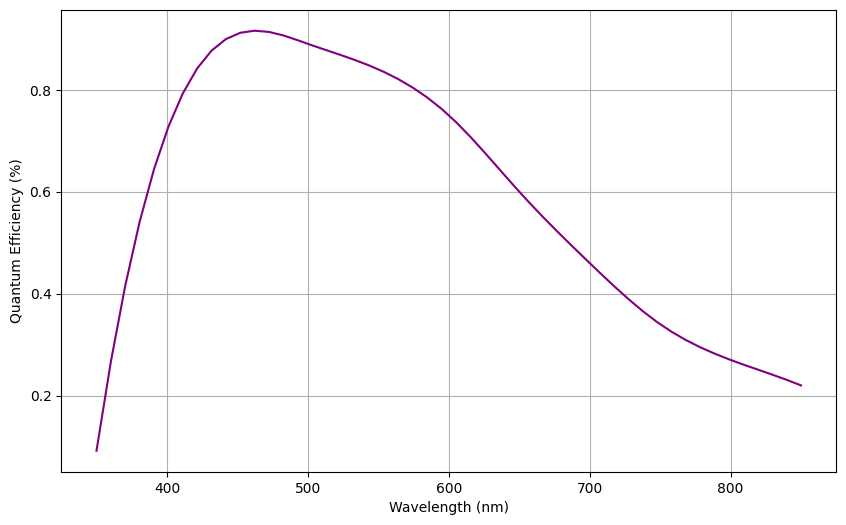

In [39]:
qe_wave = np.linspace(350, 850)
qe_curve(qe_wave)
plt.figure(figsize=(10, 6))
plt.plot(qe_wave, qe_curve(qe_wave), c='purple')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Quantum Efficiency (%)')
plt.grid();

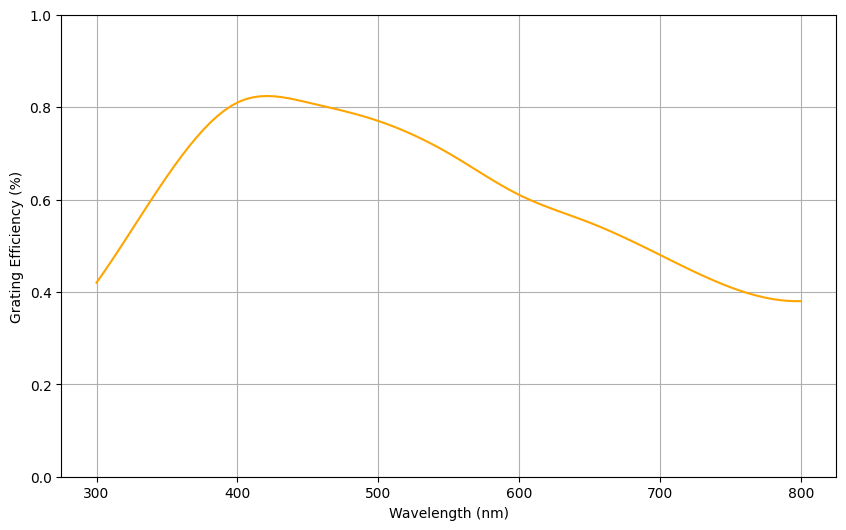

In [53]:
plot_waves_grat = [300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800]
gr_vals = [0.42, 0.65, 0.81, 0.81, 0.77, 0.70, 0.61, 0.55, 0.48, 0.41, 0.38]
gr_curve = interp1d(plot_waves_grat, gr_vals, kind='cubic', bounds_error=False, fill_value='extrapolate')

def get_gr(wave_nm):
    """takes wavelength in nm and returns grating efficiency value at that wavelength.""" 
    return float(gr_curve(wave_nm))

gr_wave = np.linspace(300, 800, 100)
plt.figure(figsize=(10, 6))
plt.plot(gr_wave, gr_curve(gr_wave), c = 'orange')
plt.ylim(0, 1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Grating Efficiency (%)')
plt.grid();

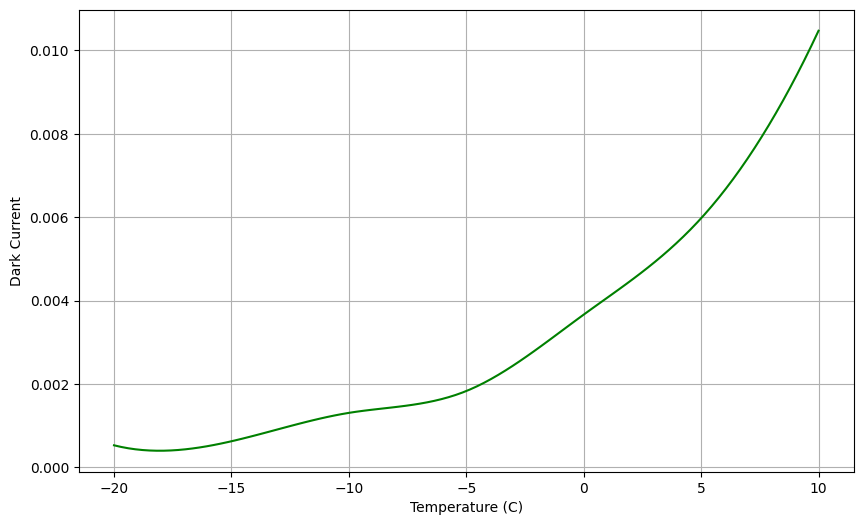

In [73]:
plot_temps_dc = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
dc_vals = [0.00053145, 0.00062832, 0.001309,
            0.0018326, 0.0036652, 0.0059756, 0.010472, 0.019111, 0.036913]
dc_curve = interp1d(plot_temps_dc, dc_vals, kind='cubic', bounds_error=False, fill_value=0.0) #not necessary to extrapolate here

def get_dc(temp_C):
    """takes temperature in C  and returns dark current value at that temperature.""" 
    return float(dc_curve(temp_C))


dc_temps = np.linspace(-20, 10, 100)
plt.figure(figsize=(10, 6))
plt.plot(dc_temps, dc_curve(dc_temps), c = 'green')
plt.xlabel('Temperature (C)')
plt.ylabel('Dark Current')
plt.grid();

In [43]:
def get_tp(detec, grat, fiber=0.995, lens=0.99):
    """Obtains the total instrument throughput from individual components"""

    total_tp = fiber * grat * lens * detec
    
    return total_tp

In [44]:
tp = get_tp(0.8, 0.6)

In [46]:
def get_flux_density(wavelength, mag_ab):
    """Determines the wavelength-dependent flux-density with a given AB-mag
    
    Wavelength is in nanometers.
    """

    wavelength = wavelength * u.nm

    f_ab = 3631 * u.Jy * np.power(10, (-mag_ab/2.5))
    f_lambda = f_ab.to(u.W/(u.m**2 * u.nm), equivalencies = u.spectral_density(wavelength))
    
    return f_lambda

get_flux_density(500,18)

<Quantity 2.74730542e-18 W / (nm m2)>

In [47]:
def get_sob(wavelength, mag_ab, throughput, t_diam = 1250):


    f_lam = get_flux_density(wavelength, mag_ab)

    t_area = np.pi * (((t_diam * u.mm).to(u.m))/2)**2

    s_ob = f_lam * (wavelength * u.nm)/(h * c) * t_area * throughput

    return s_ob.to(1/(u.s * u.nm))

get_sob(500, 18, tp)

<Quantity 4.01245002 1 / (nm s)>

In [20]:
rn_tot = (3.5+1.1)/2
pix_area = 6280 * 4210

rn_pp = rn_tot/pix_area
rn_pp

8.699335824621389e-08

In [115]:
def get_SNR(exp_time, wavelength, mag, ob_size=6.5, sky_noise=5.0, dark_current=0.001309, 
            read_noise=8.70e-8, fiber=0.995, grat=0.6, lens=0.99, detec=0.8, t_diam=1250, temp=-10, static_tp=False, use_temp_for_dc=True):
    """
    Predicts the SNR given an exposure time.
    
    Parameters:
    -----------------------------------------------

    exp_time: exposure time (s)

    wavelength: wavelength that SNR is evaluated at

    mag: apparent magnitude of object

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    read_noise: time independent detector noise (elec/pix)

    fiber: fiber attenuation (default: 0.995)

    grat: grating efficiency (default: 0.6; can be wavelength-dependent [see static_tp])

    lens: transmission fraction at lenses (default: 0.99)

    detec: quantum efficiency for detector (default: 0.8; can be wavelength-dependent [see static_tp])

    t_diam: telescope diameter (mm)

    temp: detector temperature (C) (default: -10 C)

    static_tp: if False, determines quantum efficiency (detec) and grating efficiency (grat) using the provided wavelength. If true, assumes static
    efficiencies across wavelength range.

    use_temp_for_dc: if True, determines the dark current based on the detector temperature.
    """

    if (wavelength < 400) or (wavelength > 900):
            raise(ValueError(f'Entered wavelength ({wavelength}) is outside the instrument range. Known range: 400-900 nm'))
    
    if use_temp_for_dc==True:
         if (temp < -20) or (temp > 20):
            raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
         dark_current=get_dc(temp)
    
    print('Photometric parameters:\n------------------------')
    print(f'Exposure time: {exp_time} s\nWavelength: {wavelength} nm\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
    print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')
    
    if static_tp ==True:
        tp = get_tp(detec, grat, fiber, lens)

    else:
        
        grat = get_gr(wavelength) - 0.1 #account for efficiency loss due to instrument design
        detec = get_qe(wavelength) 
        tp = get_tp(detec, grat, fiber, lens)

        
    print('Throughput parameters:\n------------------------')
    print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating: {grat:.3f}\nDetector: {detec:.3f}\nTotal Throughput: {tp:.3f}')

    s_ob = get_sob(wavelength, mag, tp).value

    numerator = s_ob * np.sqrt(exp_time)
    
    denominator = np.sqrt(s_ob + ob_size * (sky_noise + dark_current + (read_noise**2/exp_time)))

    snr = numerator/denominator

    print(f'\nSNR with entered parameters: {snr}')

In [ ]:
get_SNR(30, 450, 18)

get_SNR()

Photometric parameters:
------------------------
Exposure time: 30 s
Wavelength: 450 nm
AB Magnitude: 18
Pixel Size: 6.5 pix^2
Sky noise: 5.0 phot/s/pix
Camera temp: -10 C
Dark current: 0.001309 e/s/pix
Read noise: 8.7e-08 e/pix
Telescope diameter: 1250 mm

Throughput parameters:
------------------------
Fiber: 0.995
Lenses: 0.990
Grating: 0.710
Detector: 0.910
Total Throughput: 0.636

SNR with entered parameters: 5.296660208131922


In [112]:
def get_exptime(SNR, wavelength, mag, ob_size=6.5, sky_noise=5.0, dark_current=0.001309, 
            read_noise=8.70e-8, fiber=0.995, grat=0.6, lens=0.99, detec=0.8, t_diam=1250, temp=-10, static_tp=False, use_temp_for_dc=True):
    """Predicts the best exposure time to obtain the given SNR.
    
    Parameters:
    ------------------------------------------------

    SNR: desired signal to noise ratio

    wavelength: wavelength that SNR is evaluated at

    mag: apparent magnitude of object

    ob_size: size of object, in pixels

    sky_noise: background counts per pixel (phot/s/pix)

    dark_current: dark current (elec/s/pix)

    read_noise: time independent detector noise (elec/pix)

    fiber: fiber attenuation (default: 0.995)

    grat: grating efficiency (default: 0.6; can be wavelength-dependent [see static_tp])

    lens: transmission fraction at lenses (default: 0.99)

    detec: quantum efficiency for detector (default: 0.8; can be wavelength-dependent [see static_tp])

    t_diam: telescope diameter (mm)

    temp: detector temperature (C) (default: -10 C)

    static_tp: if False, determines quantum efficiency (detec) and grating efficiency (grat) using the provided wavelength. If true, assumes static
    efficiencies across wavelength range.

    use_temp_for_dc: if True, determines the dark current based on the detector temperature.
    """

    if (wavelength < 400) or (wavelength > 900):
            raise(ValueError(f'Entered wavelength ({wavelength}) is outside the instrument range. Known range: 400-900 nm'))
    
    if use_temp_for_dc==True:
         if (temp < -20) or (temp > 20):
            raise(ValueError(f'Entered temperature ({temp}) has no value for dark current (out of bounds). Known tempeature range: -20 to 20 C'))
         dark_current=get_dc(temp)
    
    print('Photometric parameters:\n------------------------')
    print(f'Desired SNR: {SNR}\nWavelength: {wavelength} nm\nAB Magnitude: {mag}\nPixel Size: {ob_size} pix^2\nSky noise: {sky_noise} phot/s/pix')
    print(f'Camera temp: {temp} C\nDark current: {dark_current:.6f} e/s/pix\nRead noise: {read_noise} e/pix\nTelescope diameter: {t_diam} mm\n')
    
    if static_tp ==True:
        tp = get_tp(detec, grat, fiber, lens)

    else:
        
        grat = get_gr(wavelength) - 0.1 #account for efficiency loss due to instrument design
        detec = get_qe(wavelength) 
        tp = get_tp(detec, grat, fiber, lens)

        
    print('Throughput parameters:\n------------------------')
    print(f'Fiber: {fiber:.3f}\nLenses: {lens:.3f}\nGrating: {grat:.3f}\nDetector: {detec:.3f}\nTotal Throughput: {tp:.3f}')

    s_ob = get_sob(wavelength, mag, tp).value

    C = s_ob/ob_size + sky_noise + dark_current

    exp_time = (C * ob_size * SNR**2 + np.sqrt((SNR**2 * ob_size * C)**2 + 4 * (s_ob)**2 * (read_noise**2 * ob_size * SNR**2)))/(2 * (s_ob)**2)

    print(f'\nRequired exposure time for desired SNR: {exp_time:.4f} s')

In [ ]:
get_exptime(10, 550, 16)

Photometric parameters:
------------------------
Desired SNR: 10
Wavelength: 550 nm
AB Magnitude: 16
Pixel Size: 6.5 pix^2
Sky noise: 5.0 phot/s/pix
Camera temp: -10 C
Dark current: 0.001309 e/s/pix
Read noise: 8.7e-08 e/pix
Telescope diameter: 1250 mm

Throughput parameters:
------------------------
Fiber: 0.995
Lenses: 0.990
Grating: 0.600
Detector: 0.840
Total Throughput: 0.496

Required exposure time for desired SNR: 9.7046 s
